In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
%matplotlib inline

In [2]:
!pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
x = np.linspace(-6,6,100)
def sigmoid(x):
    return 1/(1+np.exp(-x))
activations = sigmoid(x)
def sigmoid_gradient(x):
    return sigmoid(x) *(1-sigmoid(x))

In [4]:
def plot_func(x_tan=0):
    plt.plot(x, activations)
    plt.title("Sigmoid Function and Gradient")
    plt.xlabel("$x$")
    plt.ylabel("sigmoid($x$)")
    plt.text(x_tan, sigmoid(x_tan), f"Gradient:{sigmoid_gradient(x_tan):.4f}")
    plt.xlim((-6,6))
    plt.ylim((-0.5, 1.5))
    plt.rcParams['figure.figsize']= [7,5]
    y_tan = sigmoid(x_tan)
    span = 4
    data_tan = np.linspace(x_tan - span, x_tan + span)
    gradient_tan = sigmoid_gradient(x_tan)
    tan = y_tan + gradient_tan *(data_tan - x_tan)
    plt.plot(x_tan, y_tan, marker="o", color="orange", label=True)
    plt.plot(data_tan, tan, linestyle="--", color="orange")
    plt.show()
interact(plot_func, x_tan = widgets.FloatSlider(value=0,
                                                min = -6,
                                                max = 6,
                                                step = 0.5))

interactive(children=(FloatSlider(value=0.0, description='x_tan', max=6.0, min=-6.0, step=0.5), Output()), _do…

<function __main__.plot_func(x_tan=0)>

In [7]:
np.random.seed(12345)
t = 20
h = np.random.randn(5,t)
x = np.random.randn(5,t)
b_h = np.random.randn(5,1)
w_hx = np.random.randn(5,5)
eig = np.random.rand(5)*4
Q = np.random.randn(5,5)
W_hh = Q@np.diag(eig)@np.linalg.inv(Q)
print(W_hh)

[[ 2.89276193e-01 -6.02473774e+00  6.25786857e+00 -2.19032539e+01
   5.35454241e-01]
 [ 1.41260747e-01  2.35392944e+00 -1.83308196e+00  4.28223693e+00
   3.19347554e-01]
 [ 5.30703017e-01  1.51582586e+00  1.69590717e+00  3.34175529e+00
  -3.41205891e-01]
 [-3.75595730e-02 -1.13364156e-02  1.77808492e-01  1.27722888e+00
  -1.73409364e-01]
 [-1.05358526e+00 -2.96913678e+00  1.15168255e+00 -8.81472258e+00
   2.47522568e+00]]


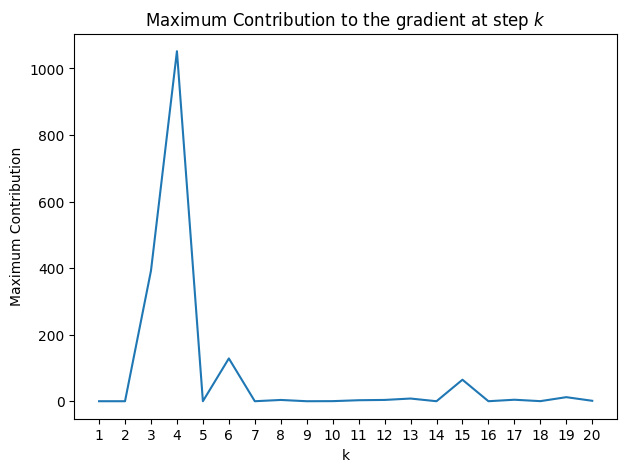

In [8]:
def prod(k):
    p = 1
    for i in range(t-1, k-2, -1):
        p *= W_hh.T@np.diag(sigmoid_gradient(w_hx@h[:,i]+w_hx@x[:,i] + b_h))
    return p

product = np.zeros(20)
for k in range(t):
    product[k] = np.max(prod(k+1))

plt.plot(np.array(range(t))+1, product)
plt.title('Maximum Contribution to the gradient at step $k$');
plt.xlabel("k")
plt.ylabel("Maximum Contribution");
plt.xticks(np.array(range(t))+1);

In [9]:
np.random.seed(12345)
t=20
h=np.zeros((5,t))
x=np.zeros((5,t))

In [10]:
h_h=np.zeros((5,1))
W_hx=np.random.randn(5,5)

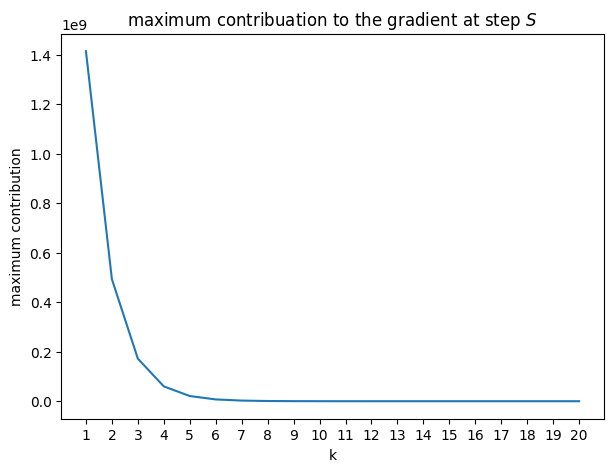

In [11]:
eig=4+np.random.rand(5)*10
Q=np.random.randn(5,5)
W_hh=Q@np.diag(eig)@np.linalg.inv(Q)

product=np.zeros(20)
for k in range(t):
    product[k]=np.max(prod(k+1))
    
plt.plot(np.array(range(t))+1,product)
plt.title("maximum contribuation to the gradient at step $S$");
plt.xlabel("k");
plt.ylabel("maximum contribution");
plt.xticks(np.array(range(t))+1);